# Sampling, extraction quality and methodology

**Psilocybin, ketamine and LSD, re-extracted from raw Reddit text (v2).**

This notebook is the machinery: where the cohort came from, what the extractor was
allowed to read, how often it had to be told it was wrong, and which denominators
every later number is conditioned on. It reports no pharmacology — notebooks 2 and 3
do that, and both stand on what is established here.

Source: `data/probes/psychedelic_pharmacology.db`, written by the second-pass probe
pipeline (`probes run psychedelic_pharmacology`). One LLM call per bounded unit of a
reporter's own text; every field is source-anchored.

**This is one of three notebooks over the same pinned extraction run.**

| | notebook | what it answers |
|---|---|---|
| 1 | `psychedelics_v2_01_methods` | who is in the cohort, what the extractor did, and how well it did it |
| 2 | `psychedelics_v2_02_overview` | the headline descriptive picture: direction, magnitude, duration, adverse events, doses |
| 3 | `psychedelics_v2_03_deep_dive` | symptom-specific heterogeneity, contrasts, robustness, and what to validate first |

They share one loader and one setup cell, and every one of them is a description
of extractable Reddit reporting patterns rather than a measurement of any drug.

### This is version 2, and it is not an update of version 1

v1 (`studies/psychedelics/v1/`) analysed community-scored `drug: outcome: symptom`
triples and asked a within-patient question: does a reporter call *this* drug helpful
more often than they call *their own* other treatments helpful. That question is not
answerable here, because this dataset contains no comparator treatments — only the
three target drugs. What this dataset has instead is everything v1 was explicitly
blocked on: dose, magnitude, duration, and adverse events with a real denominator.

The two versions therefore report different things, and **their numbers are not
comparable**. v1's odds ratios stand; nothing in these three notebooks revises them.

### What is and is not claimed

Every figure in this study is a **share of extractable reports**, with its denominator
printed next to it. None of them is an incidence, a response rate, a probability of
benefit, or a dose-response relationship. This is a self-selected Reddit cohort of
people who already wrote about these drugs; there is no denominator of people who
tried one and said nothing.

`not_stated` means the text was silent. It is never counted as an absence of adverse
events. Only `explicit_none` is a denial, and it is reported separately throughout.

## 1. Scope, unit of analysis, and privacy boundary

The unit for headline outcome estimates is a **reporter-drug pair**, and the symptom map
aggregates first to a reporter-drug-symptom-class row. This prevents multiple claims from one
account from being treated as independent observations. The report distinguishes:

- the asserted cohort pairs, planned and completed extraction units, and included claims;
- effect-bearing and adverse-event-bearing reporter-drug pairs;
- individual effect, adverse-event, and dose records used only for coverage and composition.

**On the word "reporter".** The analysis unit is a **Reddit account**, not a verified person.
The loader maps each `author_hash` to a dense integer id; that id verifies neither identity nor
one-account-per-person, so shared accounts, one person holding several accounts, and
misattributed self-reports all remain possible and unmeasured. Counts such as "1,041" are counts
of accounts. `subject=self` is a **claim-level inclusion condition applied by the extraction
schema** — the model's reading that a passage describes its author's own use — and not external
identity verification. Nothing in this notebook establishes that a reporter is a reporter, so the
word "patient" is not used for these ids anywhere in the reader-facing text.

**On the actual-use population.** The extraction schema admits a claim only when
`subject=self` **and** `exposure_status=actual_use`, so `included` and "self-reported actual
use" are the same 2,921 claims. Earlier drafts applied that filter a second time and described
it as a restriction; it removes nothing, and `P.actual_use()` asserts the identity rather than
implying a narrowing that does not occur.

**On inference.** No p-value, chi-squared test, Fisher test, or false-discovery-rate adjustment
appears in this notebook. Rows here are clustered inside reporter accounts and, in the
cross-symptom comparisons, the same account appears on both sides of a contrast — conditions that
the usual independence-assuming tests do not meet. Comparisons are therefore reported as rate
differences with **reporter-clustered bootstrap intervals**, in which whole accounts are resampled
so that an account contributing to both arms stays intact, alongside Cohen's *h* as a scale-free
effect size. Intervals are descriptive uncertainty ranges, not decision rules.

All estimates describe extractable Reddit reporting patterns, not the risk or benefit among
people exposed to any drug. The existing `psychedelics_v2.load_frames()` loader is the only
reader used here. It never selects quote-bearing fields or author hashes, maps free-text dose
fields to closed vocabularies, and discards potentially source-echoing validation errors.
This notebook is a private-review artifact and contains no verbatim Reddit quotes.

In [1]:
import html
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import HTML, display

V2_DIR = next(c for p in (Path.cwd(), *Path.cwd().parents)
              for c in (p, p / "studies/psychedelics/v2")
              if (c / "psychedelics_v2.py").is_file())
sys.path.insert(0, str(V2_DIR))
import psychedelics_v2 as P
from psychedelics_v2 import (BASE_SEED, DRUG_COLORS, MIN_PATIENTS, MIN_ROWS, N_BOOT,
                             clustered_difference, clustered_rate, cohens_h,
                             direction_profile, interval_note, meets_gate, seed_for)

# The run is pinned by full id, never resolved implicitly: a database holding
# more than one run would otherwise be settled by whichever row came back first,
# so `load_frames` raises if this id is absent or not unique.
RUN_ID = "710567555e22b68c025d8ceb1c3373564d7f9b01dcc5fe94b02b7c3209ecbc05"
DB_PATH = P.db_path()
f = P.load_frames(DB_PATH, run_id=RUN_ID)

# `included` already IS the self-reported actual-use population; `actual_use`
# asserts that identity rather than re-filtering for it.
u = P.actual_use(f)
actual_claims, actual_claim_ids = u.claims, u.claim_ids
effects, adverse, doses = u.effects, u.adverse, u.doses
actual_pairs, cohort_pairs = u.pairs, u.cohort_pairs
inc = actual_claims
pde = P.patient_drug_effects(f)

DRUGS, DIRECTIONS = list(P.DRUGS), list(P.DIRECTIONS)
SYMPTOMS = list(P.SYMPTOM_ORDER)
ROUTE_DRUG = "ketamine"   # stated route is interpreted for ketamine only
duration_labels = P.DURATION_LABELS
provenance = P.provenance_table(DB_PATH, f)

P.apply_style(plt)
sns.set_style("whitegrid")
print(f"included claims = self-reported actual use: {len(actual_claims):,} claims, "
      f"{len(actual_pairs):,} reporter-drug pairs")

included claims = self-reported actual use: 2,921 claims, 953 reporter-drug pairs


## 2. Provenance and run configuration

The cohort is 1,157 reporter-drug pairs over 1,041 reporter accounts, imported from the
legacy pipeline's asserted cohort. For each pair the planner pulled evidence windows out
of the read-only Reddit FTS corpus (`reddit_2026-06-13.db`) and packed them into units
capped at 6,000 characters. Each unit was sent once, with retries only on failure, and
the model's response was persisted **before** validation, so failures are visible rather
than silently dropped.

The run configuration below is part of the run identity: change any of it and you get a
different `run_id` and a different database.

**Snapshot date: 2026-06-13.** This is the date carried by the source snapshot's *name*,
not the period over which the underlying posts were written. The loader does not read post
timestamps, so **the content date range is unavailable** and nothing here should be read as
covering a one-day window — or any known window. Recovering it would require deliberately
loading timestamps under the privacy contract.

The cohort was imported rather than independently derived, so the reconciliation gate was
skipped: the 1,157-pair match is true by construction and does not independently confirm
the cohort (§10.2). There is a mechanical grounding floor but no item-level human
validation (§10.1). These facts are carried forward because extraction quality affects
every downstream pattern.

**Reproducing this run.** The run is pinned by full id rather than chosen implicitly. To
re-execute, point `PP_PROBE_DB` at a database whose SHA-256 matches the provenance table
below and whose `probe_run` contains `RUN_ID` as set in the setup cell; the loader raises
if that run is absent or not unique. Bootstrap seeds are derived with `crc32`, not Python's
per-process-salted `hash()`, so every interval in notebooks 2 and 3 reproduces exactly. The
seed and resample count are recorded below.

In [2]:
display(provenance.style.hide(axis="index").set_properties(**{"text-align": "left"}))
display(P.row_counts(f, u).style.hide(axis="index"))

item,value
database,psychedelic_pharmacology.db
database SHA-256,2edbe6136ec8c451e486ecd3d3b19cbdf1ed2e78e47a07c5a808f8cf137f96cc
run ID (pinned),710567555e22b68c025d8ceb1c3373564d7f9b01dcc5fe94b02b7c3209ecbc05
run created,2026-08-09T22:30:11.041289+00:00
model,deepseek/deepseek-v4-flash
provider / base URL,openai / https://openrouter.ai/api
sampling,"temperature 0.0, max_tokens 32,768, reasoning_effort high"
source snapshot,reddit_2026-06-13.db (source snapshot documented by the v2 run)
source snapshot date,2026-06-13 (the date in the snapshot name)
content date range,unavailable — post timestamps are not loaded


table/frame,rows
cohort pairs (members),1157
planned units,1206
attempts,1439
claims,3982
included = actual-use claims,2921
effects,2890
adverse events,472
doses,1338


## 3. What these notebooks are allowed to read

The probe database is quote-bearing by design: `source_window.text` is raw Reddit text, and
`claim.evidence_json` holds one verbatim quote per extracted field. `unit.author_hash` and
`cohort_member.author_hash` are re-identifiable.

`psychedelics_v2.load_frames()` is the only reader, and it enforces the boundary:

* `source_window.text` and `claim.evidence_json` are **never selected**;
* inside `claim.values_json`, the free-text `raw_text` / `raw_event` fields are dropped and
  only categorical and numeric fields are kept;
* `author_hash` is converted to a dense integer `patient` id inside the loader and the hash
  is discarded, so reporter-level grouping works and nothing re-identifiable exists
  downstream;
* the free-text dose fields (`unit`, `route`, `author_stated_intent`) are mapped into closed
  canonical vocabularies, so no patient-authored string is ever displayed;
* attempt error strings are bucketed into categories and the text itself is discarded, since
  a validation error can echo model output which can echo the source.

In [3]:
unsafe = {"quote", "evidence", "author_hash", "text", "raw_text", "raw_event"}
for name in ("members", "units", "attempts", "claims", "effects", "adverse", "doses"):
    cols = set(getattr(f, name).columns)
    assert not (cols & unsafe), f"{name} carries an unsafe column: {cols & unsafe}"
    print(f"{name:9s} {len(getattr(f, name)):>6,} rows   {sorted(cols)}")

members    1,157 rows   ['drug', 'patient']
units      1,206 rows   ['characters', 'drug', 'patient', 'status', 'unit_key', 'windows']
attempts   1,439 rows   ['attempt_no', 'billing_uncertain', 'cache_hit', 'failure', 'input_tokens', 'output_tokens', 'provider_cost', 'reasoning_tokens', 'status', 'unit_key']
claims     3,982 rows   ['adverse_event_status', 'claim_id', 'drug', 'exposure_status', 'included', 'n_adverse', 'n_doses', 'n_effects', 'patient', 'subject', 'unit_key']
effects    2,890 rows   ['claim_id', 'confidence', 'direction', 'drug', 'duration_bin', 'magnitude', 'magnitude_basis', 'n_symptom_labels', 'patient', 'sx_exertion_intolerance', 'sx_fatigue_general', 'sx_low_energy', 'sx_mood_cognitive', 'sx_pain', 'sx_pem_explicit', 'symptom_class']
adverse      472 rows   ['category', 'claim_id', 'confidence', 'drug', 'duration_bin', 'patient', 'severity']
doses      1,338 rows   ['amount_lower', 'amount_upper', 'claim_id', 'drug', 'has_context', 'has_formulation', 'has_schedul

## 4. The unit of analysis, and why the obvious one is wrong

The extraction emits one **claim** per passage discussing a target drug. 2,921 included
claims come from roughly a thousand people, so claims are **not independent**: they are
clustered inside patients, heavily and unevenly.

A proportion computed over claims is pseudo-replication. Its point estimate is a
weighted average that lets the most prolific posters vote many times, and its Wilson
interval — which assumes independent draws — is far too narrow.

So every headline rate below is computed at the **(patient, drug) pair** level: a reporter's
claims for one drug are collapsed to one value, e.g. "reported at least one helped effect
for psilocybin". Event-level tables are still shown where the shape of the data matters,
and they are always labelled event-level and never given an independence-assuming interval.

In [4]:
pde = P.patient_drug_effects(f)
share = pde.n_effects.sort_values(ascending=False)
top_pct = share.head(max(1, len(share) // 100)).sum() / share.sum()

print(f"effect records                       {len(f.effects):,}")
print(f"(patient, drug) pairs producing them {len(pde):,}")
print(f"median effect records per pair       {share.median():.0f}   max {share.max()}")
print(f"share of all effect records from the top 1% of pairs: {top_pct:.1%}")

effect records                       2,890
(patient, drug) pairs producing them 747
median effect records per pair       2   max 251
share of all effect records from the top 1% of pairs: 18.7%


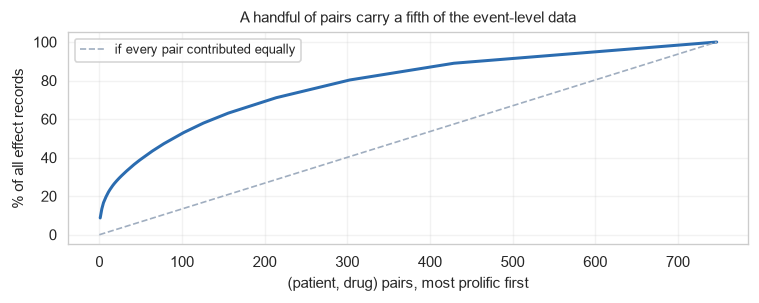

In [5]:
fig, ax = plt.subplots(figsize=(6.4, 2.6))
ax.plot(np.arange(1, len(share) + 1), 100 * share.sort_values(ascending=False).cumsum()
        / share.sum(), color=P.COLORS["accent"], lw=1.8)
ax.plot([0, len(share)], [0, 100], color=P.COLORS["muted"], lw=1, ls="--",
        label="if every pair contributed equally")
ax.set_xlabel("(patient, drug) pairs, most prolific first")
ax.set_ylabel("% of all effect records")
ax.set_title("A handful of pairs carry a fifth of the event-level data", fontsize=9)
ax.legend(fontsize=7.5)
plt.tight_layout(); plt.show()

## 5. The extraction contract

Each claim carries the model's own labels for two questions it was asked to decide
semantically, with an evidence quote for each:

| field | values |
|---|---|
| `subject` | `self` / `other` / `unclear` |
| `exposure_status` | `actual_use` / `planned_or_considered` / `declined_or_never` / `unclear` |

A claim is **included** only when `subject=self` **and** `exposure_status=actual_use`.
Only included claims may carry doses, effects or adverse events; the schema rejects a
response that attaches an outcome to someone else's use or to a use that never happened.

Excluded claims are kept deliberately. They are the denominator: they show what the model
considered and set aside, which is the only way to inspect whether the inclusion rule is
doing the right thing.

---
# 6. Cohort, units and denominators

## 6.1 From cohort pairs to extracted claims

Four denominators are in play and they must not be confused: cohort pairs, planned units,
completed units, and claims. Each is smaller in a different way than the one before.

In [6]:
cohort = f.members.groupby("drug").size().rename("cohort_pairs")
units = f.units.groupby(["drug", "status"]).size().unstack(fill_value=0)
inc = f.claims[f.claims.included]

summary = pd.DataFrame({
    "cohort_pairs": cohort,
    "units_planned": f.units.groupby("drug").size(),
    "units_complete": units.get("complete", 0),
    "units_failed": units.get("failed", 0),
    "claims_total": f.claims.groupby("drug").size(),
    "claims_included": inc.groupby("drug").size(),
    "claims_excluded": f.claims[~f.claims.included].groupby("drug").size(),
    "pairs_with_included_claim": inc.groupby("drug").patient.nunique(),
}).reindex(list(P.DRUGS)).fillna(0).astype(int)
summary.loc["total"] = summary.sum()
display(summary)

print(f"distinct patients in the cohort          {f.members.patient.nunique():,}")
print(f"distinct patients with an included claim {inc.patient.nunique():,}")
print(f"source windows packed into units         {f.units.windows.sum():,}")
print(f"characters sent                          {f.units.characters.sum():,}")

,cohort_pairs,units_planned,units_complete,units_failed,claims_total,claims_included,claims_excluded,pairs_with_included_claim
drug,,,,,,,,
psilocybin,538,528,524,4,1687,1172,515,415
ketamine,525,589,581,8,2078,1588,490,463
lsd,94,89,87,2,217,161,56,75
total,1157,1206,1192,14,3982,2921,1061,953


distinct patients in the cohort          1,041
distinct patients with an included claim 878
source windows packed into units         4,180
characters sent                          2,182,844


## 6.2 What the excluded claims are

1,061 of 3,982 claims are excluded. That is not waste; it is the classifier working. The
largest single bucket by far is `unclear` on both axes (493) — passages where the text names
the drug but never anchors who took it or whether they took it. Then come the author's own
stated intention to try (217) and other people's use (261 across all statuses).

A run in which almost nothing landed in `planned_or_considered` or `other` would be evidence
the model was not really classifying. That is not what happened.

exposure_status,actual_use,declined_or_never,planned_or_considered,unclear
subject,,,,
other,151,0,27,83
self,0,18,217,57
unclear,10,0,5,493


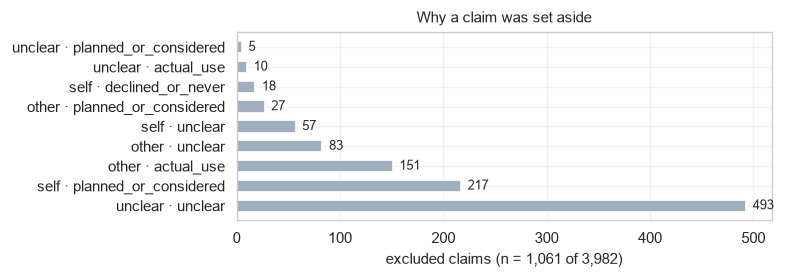

In [7]:
ex = f.claims[~f.claims.included]
tab = pd.crosstab(ex.subject, ex.exposure_status)
display(tab)

fig, ax = plt.subplots(figsize=(6.6, 2.4))
flat = tab.stack().sort_values()
flat = flat[flat > 0]
P.counts_bars(ax, [f"{s} · {st}" for s, st in flat.index], flat.values,
              color=P.COLORS["muted"])
ax.set_xlabel(f"excluded claims (n = {len(ex):,} of {len(f.claims):,})")
ax.set_title("Why a claim was set aside", fontsize=9)
plt.tight_layout(); plt.show()

## 6.3 The gap between the cohort and the analysable set

Being in the cohort does not mean producing an analysable report. A pair drops out at four
separate points: its unit can fail extraction, its text can turn out to only mention the
drug in passing, its claims can all be excluded, and even an included claim need not carry
an effect. Only the last column is what the effect-direction section actually stands on.

,cohort pairs,pairs with any claim,pairs with an included claim,pairs with an effect record,% of cohort reaching an effect
drug,,,,,
psilocybin,538,464,415,341,63.4
ketamine,525,501,463,352,67.0
lsd,94,83,75,54,57.4


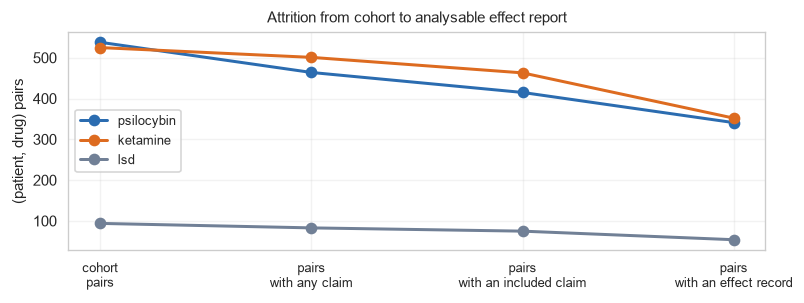

In [8]:
funnel = pd.DataFrame({
    "cohort pairs": f.members.groupby("drug").size(),
    "pairs with any claim": f.claims.groupby("drug").apply(
        lambda d: d.groupby("patient").ngroups, include_groups=False),
    "pairs with an included claim": inc.groupby("drug").apply(
        lambda d: d.groupby("patient").ngroups, include_groups=False),
    "pairs with an effect record": pde.groupby("drug").size(),
}).reindex(list(P.DRUGS)).fillna(0).astype(int)
funnel["% of cohort reaching an effect"] = (
    100 * funnel["pairs with an effect record"] / funnel["cohort pairs"]).round(1)
display(funnel)

fig, ax = plt.subplots(figsize=(6.8, 2.6))
steps = list(funnel.columns[:4])
x = np.arange(len(steps))
for d, color in zip(P.DRUGS, ["#2b6cb0", "#dd6b20", "#718096"]):
    ax.plot(x, funnel.loc[d, steps].values, "o-", color=color, lw=1.8, label=d)
ax.set_xticks(x, [s.replace(" ", "\n", 1) for s in steps], fontsize=7.5)
ax.set_ylabel("(patient, drug) pairs")
ax.set_title("Attrition from cohort to analysable effect report", fontsize=9)
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

---
# 7. Reporting funnel and missingness

The extraction path has several different denominators. A completed unit is an extraction
unit, whereas an included claim is a claim event and an effect-bearing pair is a reporter-drug
pair. These are not interchangeable. 953 of the 1,157 cohort pairs carry at least one included
claim — and because inclusion *is* the actual-use rule, that is also the actual-use population.
Silence in a downstream field is missing information, not evidence that the event or field was
absent.

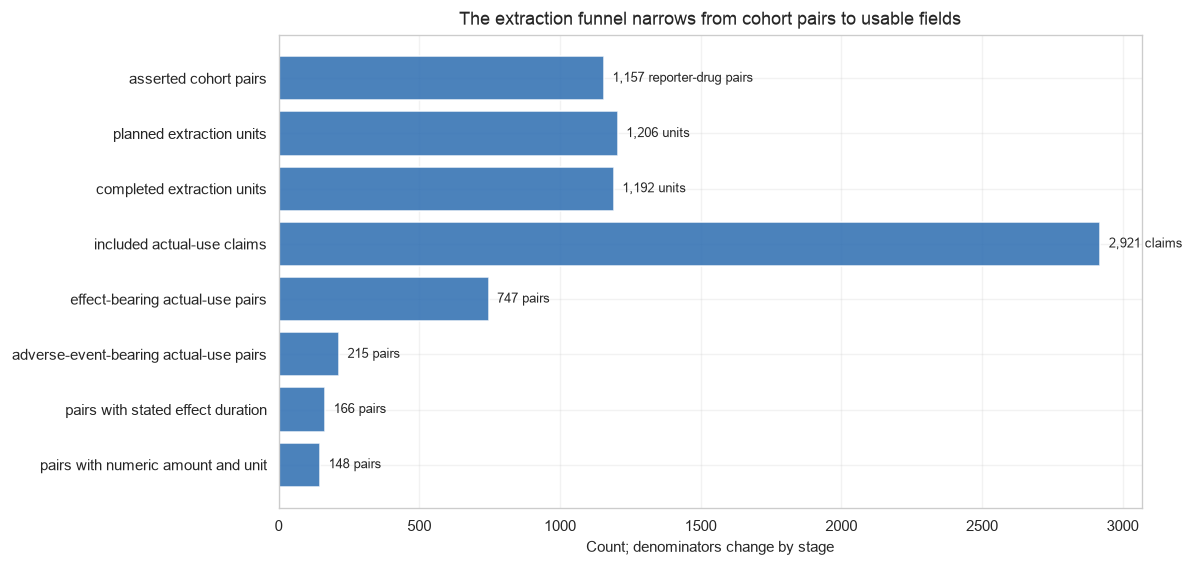

In [9]:
effect_pairs = effects[["patient", "drug"]].drop_duplicates()
ae_pairs = adverse[["patient", "drug"]].drop_duplicates()
duration_effect_pairs = effects.loc[
    effects["duration_bin"].notna(), ["patient", "drug"]
].drop_duplicates()
numeric_dose_pairs = doses.loc[
    doses["amount_lower"].notna() & doses["unit_canon"].notna(),
    ["patient", "drug"],
].drop_duplicates()
funnel = pd.DataFrame([
    {"stage": "asserted cohort pairs", "count": len(cohort_pairs), "unit": "reporter-drug pairs"},
    {"stage": "planned extraction units", "count": len(f.units), "unit": "units"},
    {"stage": "completed extraction units", "count": int(f.units["status"].eq("complete").sum()), "unit": "units"},
    {"stage": "included actual-use claims", "count": len(actual_claims), "unit": "claims"},
    {"stage": "effect-bearing actual-use pairs", "count": len(effect_pairs), "unit": "pairs"},
    {"stage": "adverse-event-bearing actual-use pairs", "count": len(ae_pairs), "unit": "pairs"},
    {"stage": "pairs with stated effect duration", "count": len(duration_effect_pairs), "unit": "pairs"},
    {"stage": "pairs with numeric amount and unit", "count": len(numeric_dose_pairs), "unit": "pairs"},
])
fig, ax = plt.subplots(figsize=(10, 4.8))
plot_funnel = funnel.iloc[::-1]
y = np.arange(len(plot_funnel))
ax.barh(y, plot_funnel["count"], color="#2b6cb0", alpha=0.85)
ax.set_yticks(y, plot_funnel["stage"])
ax.set_xlabel("Count; denominators change by stage")
ax.set_title("The extraction funnel narrows from cohort pairs to usable fields")
for yi, (_, r) in zip(y, plot_funnel.iterrows()):
    ax.annotate(f"{r['count']:,} {r['unit']}", (r["count"], yi), xytext=(5, 0),
                textcoords="offset points", va="center", fontsize=8)
fig.tight_layout()
display(fig)
plt.close(fig)


In [10]:
def percentage(k, n):
    return np.nan if not n else 100 * k / n

coverage_rows = []
for drug in DRUGS:
    ap = actual_pairs[actual_pairs["drug"].eq(drug)]
    ep = effect_pairs[effect_pairs["drug"].eq(drug)]
    aep = ae_pairs[ae_pairs["drug"].eq(drug)]
    dep = duration_effect_pairs[duration_effect_pairs["drug"].eq(drug)]
    ndp = numeric_dose_pairs[numeric_dose_pairs["drug"].eq(drug)]
    coverage_rows.append({
        "drug": drug,
        "actual-use pairs": len(ap),
        "effect-bearing pairs": len(ep),
        "effect coverage %": percentage(len(ep), len(ap)),
        "AE-bearing pairs": len(aep),
        "AE coverage %": percentage(len(aep), len(ap)),
        "stated-duration pairs": len(dep),
        "duration among effect pairs %": percentage(len(dep), len(ep)),
        "numeric-dose pairs": len(ndp),
        "numeric dose among actual pairs %": percentage(len(ndp), len(ap)),
    })
coverage = pd.DataFrame(coverage_rows)
display(coverage.style.format(precision=1, na_rep="—").hide(axis="index"))


drug,actual-use pairs,effect-bearing pairs,effect coverage %,AE-bearing pairs,AE coverage %,stated-duration pairs,duration among effect pairs %,numeric-dose pairs,numeric dose among actual pairs %
psilocybin,415,341,82.2,80,19.3,91,26.7,107,25.8
ketamine,463,352,76.0,114,24.6,63,17.9,29,6.3
lsd,75,54,72.0,21,28.0,12,22.2,12,16.0


The field-level denominator also changes inside a pair. The following matrix separates
coverage of effects and adverse events among actual-use pairs from coverage of duration,
dose, route, intent, formulation, schedule, and context among records where that record type
exists. A missing value remains explicit.

The `route` row is reported for all three drugs as coverage, but **it is only interpreted for
ketamine** (notebook 3, §5): ketamine is the one arm where stated route varies at all, separating IV/IM from
self-administered exposure, psilocybin is oral wherever stated, and no LSD dose record states a
route at all.

In [11]:
dose_field_rows = []
for drug in DRUGS:
    ds = doses[doses["drug"].eq(drug)]
    es = effects[effects["drug"].eq(drug)]
    ass = adverse[adverse["drug"].eq(drug)]
    dose_n = len(ds)
    dose_field_rows.extend([
        {"drug": drug, "field": "effect-bearing pair", "reported": len(effect_pairs[effect_pairs["drug"].eq(drug)]), "denominator": len(actual_pairs[actual_pairs["drug"].eq(drug)])},
        {"drug": drug, "field": "adverse-event-bearing pair", "reported": len(ae_pairs[ae_pairs["drug"].eq(drug)]), "denominator": len(actual_pairs[actual_pairs["drug"].eq(drug)])},
        {"drug": drug, "field": "effect duration", "reported": int(es["duration_bin"].notna().sum()), "denominator": len(es)},
        {"drug": drug, "field": "dose amount + unit", "reported": int((ds["amount_lower"].notna() & ds["unit_canon"].notna()).sum()), "denominator": dose_n},
        {"drug": drug, "field": "route", "reported": int(ds["route_canon"].notna().sum()), "denominator": dose_n},
        {"drug": drug, "field": "stated intent", "reported": int(ds["intent_canon"].notna().sum()), "denominator": dose_n},
        {"drug": drug, "field": "formulation", "reported": int(ds["has_formulation"].sum()), "denominator": dose_n},
        {"drug": drug, "field": "schedule", "reported": int(ds["has_schedule"].sum()), "denominator": dose_n},
        {"drug": drug, "field": "treatment context", "reported": int(ds["has_context"].sum()), "denominator": dose_n},
    ])
missingness = pd.DataFrame(dose_field_rows)
missingness["coverage %"] = np.where(
    missingness["denominator"] > 0,
    100 * missingness["reported"] / missingness["denominator"],
    np.nan,
)
missingness_matrix = missingness.pivot(index="field", columns="drug", values="coverage %").reindex(
    ["effect-bearing pair", "adverse-event-bearing pair", "effect duration", "dose amount + unit",
     "route", "stated intent", "formulation", "schedule", "treatment context"]
)
display(missingness_matrix.style.format("{:.1f}%", na_rep="—"))


drug,ketamine,lsd,psilocybin
field,,,
effect-bearing pair,76.0%,72.0%,82.2%
adverse-event-bearing pair,24.6%,28.0%,19.3%
effect duration,6.8%,13.4%,11.2%
dose amount + unit,9.0%,25.7%,27.6%
route,64.8%,0.0%,15.4%
stated intent,15.3%,58.1%,55.7%
formulation,18.7%,6.8%,19.9%
schedule,30.5%,18.9%,22.2%
treatment context,46.3%,6.8%,8.3%


---
# 8. Extraction reliability

Before any pharmacology, the machinery itself. This section is the honest part of the
paper: it says how often the extractor had to be told it was wrong, and in what way.

## 8.1 Attempts

1,206 units were planned and 1,192 completed. It took 1,439 attempts to get there — a
validation failure feeds its own error back to the model as retry feedback, up to three
attempts, and a transport failure is retried too.

In [12]:
display(P.attempt_summary(f))

apu = P.attempts_per_unit(f)
piv = apu.pivot(index="attempts", columns="status", values="units").fillna(0).astype(int)
display(piv)
print(f"units needing more than one attempt: "
      f"{int(piv.loc[piv.index > 1].values.sum())} of {len(f.units):,}")

,value
metric,
attempts,1439
accepted,1192
validation_failed,179
transport_failed,68
cache_hits,0
billing_uncertain,65
attempts with usage recorded,1374
input tokens,4540712
output tokens,6554148


status,complete,failed
attempts,,
1,1045,3
2,104,1
3,28,9
4,12,0
5,2,0
6,1,1


units needing more than one attempt: 158 of 1,206


## 8.2 Failure categories

Error strings are not shown — a validation error can quote the model's output back, which
can quote the source. They are bucketed instead.

Two things are worth reading carefully. **`outcomes_on_excluded_event`** (45 attempts) is
the model attaching a dose or effect to a passage it had itself labelled as someone else's
use or a use that never happened; the schema rejects that, and the retry usually fixes it.
**`quote_not_grounded`** (22 attempts) is the mechanical anti-fabrication floor: a quote
must share at least half its words with the window it cites. At this volume the guard is
working rather than fighting the prompt.

`connection_error` and `timeout` are transport, not model behaviour — see §8.4.

,status,failure,attempts,units
0,transport_failed,connection_error,45,27
1,transport_failed,timeout,19,17
2,transport_failed,null_content,3,3
3,transport_failed,other_schema_error,1,1
4,validation_failed,outcomes_on_excluded_event,45,41
5,validation_failed,wrong_source_reference,39,33
6,validation_failed,other_schema_error,33,31
7,validation_failed,quote_not_grounded,22,19
8,validation_failed,empty_quote,21,20
9,validation_failed,adverse_status_inconsistent,12,12


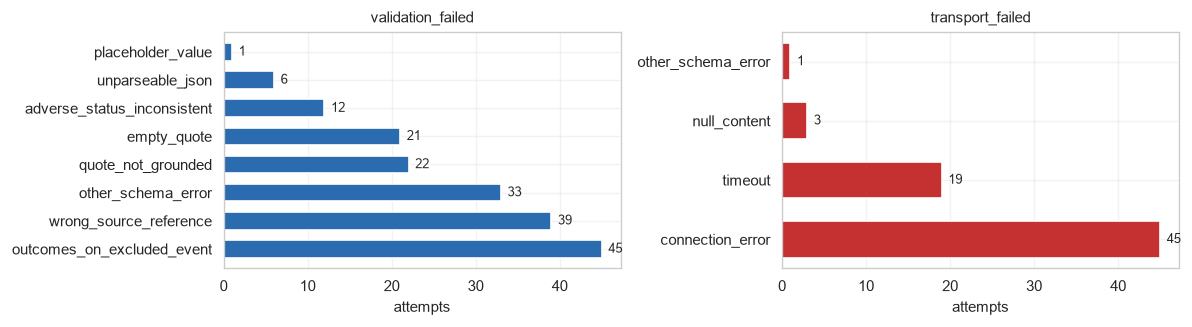

In [13]:
ft = P.failure_table(f)
display(ft)

fig, axes = plt.subplots(1, 2, figsize=(10, 2.8))
for ax, status in zip(axes, ["validation_failed", "transport_failed"]):
    sub = ft[ft.status == status].sort_values("attempts")
    P.counts_bars(ax, sub.failure.tolist(), sub.attempts.tolist(),
                  color=P.COLORS["worsened"] if status == "transport_failed"
                  else P.COLORS["accent"])
    ax.set_xlabel("attempts")
    ax.set_title(status, fontsize=9)
plt.tight_layout(); plt.show()

## 8.3 The 14 units that never succeeded

Fourteen units exhausted their attempts and are marked `failed`. Their patients are not
necessarily absent from the analysis — a pair can span several units — but the text in
these units contributed nothing.

Eleven further units completed with **zero claims**. That is a legitimate outcome: a window
can match the drug keyword while only mentioning it in passing.

In [14]:
failed = f.units[f.units.status == "failed"]
empty = f.units[(f.units.status == "complete") & (~f.units.unit_key.isin(f.claims.unit_key))]

display(pd.DataFrame({
    "failed units": failed.groupby("drug").size(),
    "failed: patients affected": failed.groupby("drug").patient.nunique(),
    "complete but zero claims": empty.groupby("drug").size(),
}).reindex(list(P.DRUGS)).fillna(0).astype(int))

lost = failed.characters.sum()
print(f"characters in failed units: {lost:,} "
      f"({100 * lost / f.units.characters.sum():.2f}% of the corpus sent)")
print("failure category of the last attempt on each failed unit:")
last = (f.attempts[f.attempts.unit_key.isin(failed.unit_key)]
        .sort_values("attempt_no").groupby("unit_key").tail(1))
display(last.failure.value_counts().rename("units").to_frame())

,failed units,failed: patients affected,complete but zero claims
drug,,,
psilocybin,4,4,8
ketamine,8,8,2
lsd,2,2,1


characters in failed units: 58,813 (2.69% of the corpus sent)
failure category of the last attempt on each failed unit:


,units
failure,
wrong_source_reference,4
null_content,3
other_schema_error,2
outcomes_on_excluded_event,2
quote_not_grounded,2
empty_quote,1


## 8.4 Cost, tokens, and the attempts that cannot be accounted for

Reasoning tokens bill as output tokens, and at `reasoning_effort=high` they dominate: the
thinking trace is about four fifths of everything generated.

**65 attempts are `billing_uncertain`** — transport failed before usage could be read, so
they may or may not have been billed. They are named here rather than folded into a total.
Most of them come from a phase of the run when the client read timeout was 60s, which
preferentially killed long-reasoning units; the timeout was later raised to 90s and the
affected units were retried and recovered. The early attempt ledger is therefore **not a
clean sample of transport reliability**.

provider-reported cost over 1,374 attempts: $2.07
attempts with no usage recorded: 65 (of which 65 are flagged billing_uncertain)
reasoning tokens as a share of output: 79.3%
cost per completed unit: $0.0017


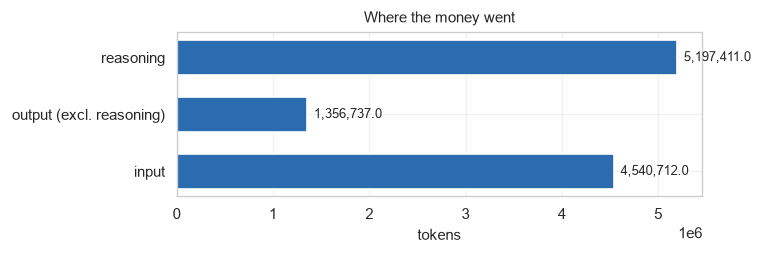

In [15]:
a = f.attempts
cost = a.provider_cost.fillna(0).sum()
print(f"provider-reported cost over {int(a.provider_cost.notna().sum()):,} attempts: "
      f"${cost:.2f}")
print(f"attempts with no usage recorded: {int(a.provider_cost.isna().sum())} "
      f"(of which {int(a.billing_uncertain.sum())} are flagged billing_uncertain)")
print(f"reasoning tokens as a share of output: "
      f"{a.reasoning_tokens.fillna(0).sum() / a.output_tokens.fillna(0).sum():.1%}")
print(f"cost per completed unit: ${cost / int((f.units.status == 'complete').sum()):.4f}")

fig, ax = plt.subplots(figsize=(6.4, 2.2))
tok = pd.Series({
    "input": a.input_tokens.fillna(0).sum(),
    "output (excl. reasoning)": a.output_tokens.fillna(0).sum() - a.reasoning_tokens.fillna(0).sum(),
    "reasoning": a.reasoning_tokens.fillna(0).sum(),
})
P.counts_bars(ax, tok.index.tolist()[::-1], tok.values.tolist()[::-1],
              color=P.COLORS["accent"])
ax.set_xlabel("tokens")
ax.set_title("Where the money went", fontsize=9)
plt.tight_layout(); plt.show()

---
# 9. Inference: the evidence gate and reporter-clustered intervals

Notebooks 2 and 3 report **no p-value, chi-squared test, Fisher test, or false-discovery-rate
adjustment**. Rows are clustered inside reporter accounts and, in the cross-symptom
comparisons, the same account appears on both sides of a contrast — conditions the usual
independence-assuming tests do not meet. Three rules apply throughout, and all three live in
`psychedelics_v2.py` so the two analysis notebooks share one implementation:

1. **The evidence gate.** A cell carrying fewer than **20 rows** or **10 reporter accounts**
   (`P.MIN_ROWS`, `P.MIN_PATIENTS`) is labelled `insufficient`. It is displayed so the reader
   can see how thin it is, and excluded from every headline, ranking and tier.
2. **Reporter-clustered bootstrap intervals.** `P.clustered_rate` and
   `P.clustered_difference` resample **whole accounts**, 2,000 times, so an account that
   contributes rows to both arms of a contrast stays intact and the dependence between the
   arms is carried into the interval instead of being assumed away. Both arms of a difference
   are recomputed inside a single resample, so the comparator carries its own uncertainty.
3. **Effect size, and a description rather than a decision.** Every difference is stated in
   percentage points alongside Cohen's *h*. "Interval clear of zero" describes where an
   interval sits; it is not a test decision, and no threshold promotes a row to a finding.

Seeds are derived with `crc32` (`P.seed_for`) rather than Python's per-process-salted
`hash()`, so every interval reproduces exactly on re-execution.

An interval here covers **sampling only**. It does not cover extraction error, and §10.4
gives the reason that gap is likely to be large.

---
# 10. What extraction quality means for every number downstream

These are not caveats appended to a result. Several of them are load-bearing enough that
everything in notebooks 2 and 3 should be read as *a description of what an unvalidated
extractor produced from a self-selected forum*, and not as a measurement of anything about
these drugs.

## 10.1 GATE 4 was bypassed, not satisfied

The runbook requires a human to read a sample of claims against their source windows and
confirm that each quote actually supports the field it was attached to. **That has not
happened.** No person has verified a single claim in this database at the item level.

What did run is the mechanical grounding floor: a quote must share at least half its words
with the window it cites (22 attempts were rejected for failing it, §8.2). That guard
catches fabrication. It cannot catch a real quote attached to the wrong field, a dose
credited to the wrong drug in a stack, or a plan read as a use.

Everything in notebooks 2 and 3 is therefore **unvalidated at the item level**. The
per-field precision and recall gates the protocol specifies — 100% quote/source integrity,
≥95% drug attribution and self-report accuracy, ≥90% precision on dose, duration and adverse
events — are unmeasured, not met.

## 10.2 The cohort was imported, so the reconciliation check is unanswered

The runbook's GATE 1 asks whether two independent derivations of the cohort agree: the
legacy pipeline's JSON-derived cohort, and this pipeline's SQL-derived one. This run's
cohort was **imported from the legacy run's JSON**, so the exact 1,157 / 538 / 525 / 94
match is true by construction and confirms nothing. The two derivations remain unreconciled.

## 10.3 An unexplained discrepancy in the planned unit set

Against the legacy reference: source windows match exactly (4,180), total characters match
exactly (2,182,844) — but this run planned **1,206** units against the legacy ~1,207, and its
largest unit is **5,998** characters against 5,990.

Identical inputs producing an identical window set and an identical character total, yet a
different packing, is not explained. It is small, but it means the two unit sets are not the
same object and a per-unit comparison across the versions is not safe.

## 10.4 The extractor is unstable at the record level

The corpus README documents two identical LLM passes over the same text agreeing on the
**field set only 36.5%** of the time and on **values 58.8%** of the time. That instability
has not been re-measured for this pipeline; no repeat-pass check was run.

The consequence is a hard rule: **cohort aggregates only.** No individual's record in this
database should be treated as a stable description of that person, and no per-person story
should be built from it. It is also the reason to read every rate in notebooks 2 and 3 as
having an error term much larger than its interval — the interval covers sampling, not
extraction noise.

## 10.5 The attempt ledger is not a clean sample

68 transport failures and 65 `billing_uncertain` attempts (§8.4). Most came from a phase of
the run when the client read timeout was 60 seconds, which preferentially killed
long-reasoning units — i.e. the failures are correlated with unit difficulty, not random.
The timeout was later raised to 90s and the affected units were retried and recovered, so
the completed set is fine; the **failure statistics** in §8.1–8.2 are not a clean sample of
anything.

The limitations that concern the *findings* rather than the machinery are in notebook 2, §6
and notebook 3, §11.

---
## Reproducing this notebook

```bash
cd studies/psychedelics/v2
uv run jupyter nbconvert --to notebook --execute --inplace psychedelics_v2_01_methods.ipynb
uv run python _export_html.py
```

The database is opened read-only through a `file:…?mode=ro` URI and is never written.
`PP_PROBE_DB` overrides its location.

In [16]:
display(HTML(
    '<div style="font-size: 1.2em; font-weight: bold; font-style: italic; margin-top: 1em;">'
    'These findings reflect reporting patterns in online communities, not population-level '
    'treatment effects. This is not medical advice.'
    '</div>'
))
